In [24]:
import pandas as pd
df = pd.read_csv('advertising.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [25]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


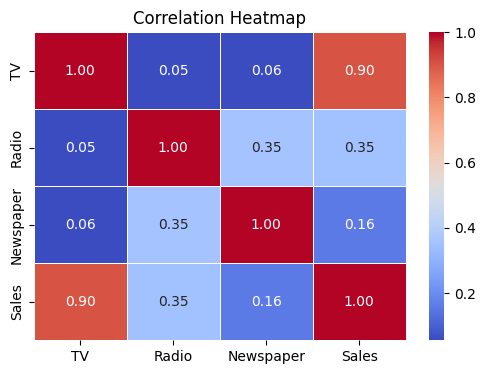

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

T.V. shows the the highest correlation - +0.90 (strong)

Newspaper - +0.06(weaker)

Radio - +0.05 (weakest)

In [27]:
#Insight - T.V. has the strongest impact on sales because it shows the highest positive correlation of +0.9 with the Sales variable.
#with T.V.
from sklearn.model_selection import train_test_split

X = df[['TV','Radio','Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
#Using multiple regression models and finding the best one
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
}

In [29]:
from sklearn.metrics import r2_score

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name} R2: {r2_score(y_test, preds):.4f}")

Linear Regression R2: 0.9059
Ridge Regression R2: 0.9059
Lasso Regression R2: 0.9059
Decision Tree R2: 0.9001
Random Forest R2: 0.9491


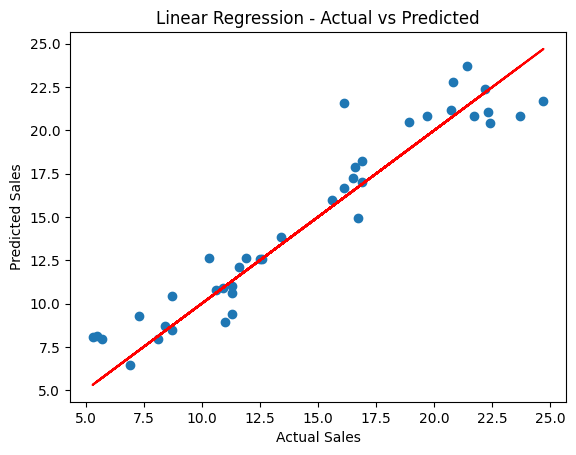

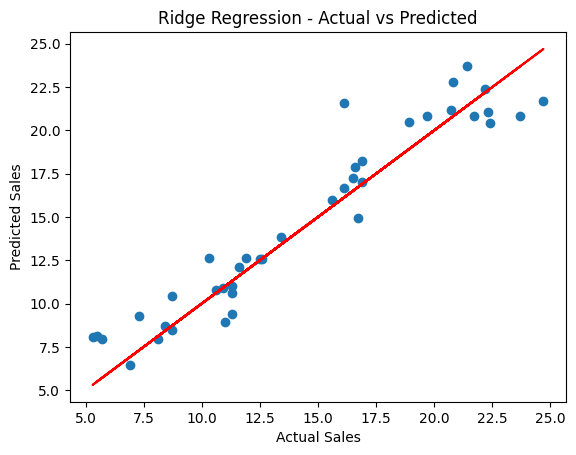

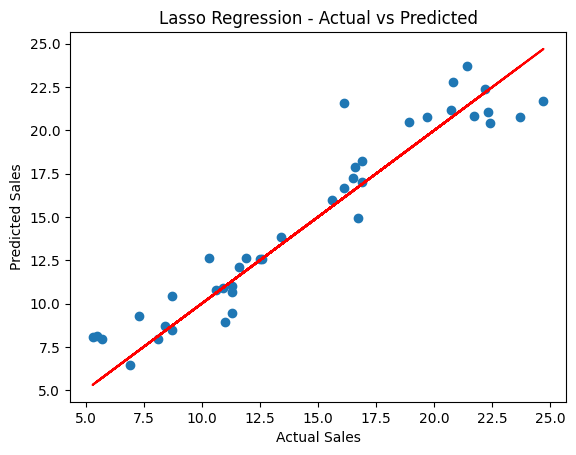

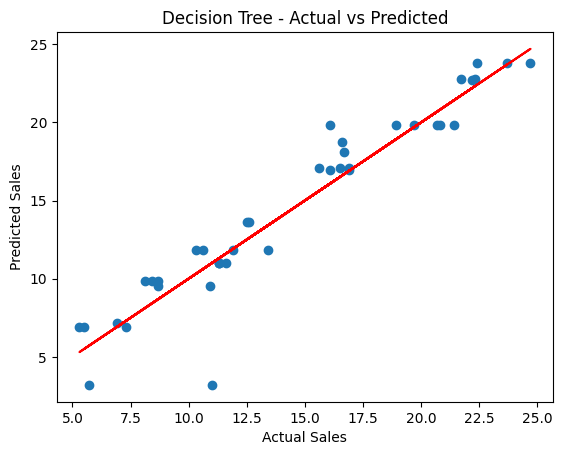

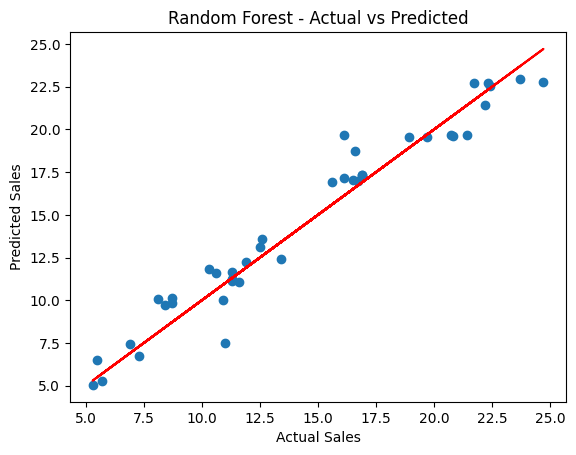

In [ ]:
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    plt.figure()
    plt.scatter(y_test, preds)
    plt.plot(y_test, y_test,color='red')   
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.title(f"{name} - Actual vs Predicted")
    plt.show()

Random Forest achieved the highest R2=0.9491 better than all other models and the  and capturing non-linear patterns in the data, therefore Random Forest is selected as the best-fit model
It will maximize the sales.